# HCP Call Optimizer: End-to-End

The most ambitious template in the package. We run the full
`DetailOptimizationPipeline` on synthetic US data: load → engineer features →
train probability/depth/look-alike models → score scenarios → solve a PuLP LP
to allocate a finite call budget across HCPs and territories → write a long
portfolio.

This is what 1,500 lines of brittle pharma-notebook compresses into.

In [1]:
# Run once per session. In Colab, this installs into the runtime;
# in local Jupyter, it goes to the active kernel's environment.
import sys, subprocess
def _ensure(pkg, import_name=None):
    name = import_name or pkg.split('[')[0].split('==')[0]
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# In Colab/Jupyter, install ai2analytics from GitHub. If it's already
# installed locally (editable), this is a no-op.
try:
    import ai2analytics  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'git+https://github.com/jamesyoung93/AI2Analytics.git'])

# Plot helpers (matplotlib is already a hard dep of ai2analytics)
_ensure('matplotlib')
print('Setup complete.')

Setup complete.


## 1. Generate a self-contained US HCP dataset

Seven tables: HCP reference, weekly activity, calls, two team alignments,
portfolio decile, priority targets.

In [2]:
from ai2analytics.datasets import us_hcp
tables = us_hcp.generate_all(seed=42)
{name: df.shape for name, df in tables.items()}

Generating synthetic US HCP data (seed=42) ...
  hcp_reference:        5,000 rows


  hcp_weekly:         114,011 rows


  calls:               32,726 rows
  team_a_alignment:     4,255 rows
  team_b_alignment:     3,964 rows
  portfolio_decile:     5,000 rows
  priority_targets:       500 rows
Done.



{'hcp_reference': (5000, 5),
 'hcp_weekly': (114011, 8),
 'calls': (32726, 3),
 'team_a_alignment': (4255, 2),
 'team_b_alignment': (3964, 2),
 'portfolio_decile': (5000, 2),
 'priority_targets': (500, 2)}

## 2. Configure the pipeline

`DetailOptimizationConfig` exposes every column name, every model param, every
optimizer constraint. Defaults are sensible — we override only what's specific
to this synthetic schema.

In [3]:
from ai2analytics.templates.detail_optimization import (
    DetailOptimizationConfig, DetailOptimizationPipeline,
)

cfg = DetailOptimizationConfig(
    drug_name='SYNTH_DRUG',
    drug_portfolio='SYNTH_PORTFOLIO',
    # Override IL-17/IL-23 -> decile bin columns the synthetic data exposes
    il_rx_columns=[
        ('IL_17_TRX_L12M', 'IL_17_DECILE'),
        ('IL_23_TRX_L12M', 'IL_23_DECILE'),
    ],
    # Use lighter models so the demo runs in <1 min on a Colab CPU
    n_backtest_folds=3,
    backtest_gap_weeks=4,
    prob_model_params={'n_estimators': 60, 'max_depth': 6, 'random_state': 42},
    depth_model_params={'n_estimators': 60, 'max_depth': 12,
                        'min_samples_leaf': 4, 'n_jobs': -1, 'random_state': 42},
    look_model_params={'n_estimators': 60, 'max_depth': 5, 'random_state': 42},
    # Smaller per-territory budgets keep the LP fast
    team_a_budget_per_territory=80,
    team_b_target_per_territory=60,
    output_csv='detail_optimization_plan.csv',
)

## 3. Run end-to-end

Stages C–J: load, features, train, score, optimize, post-process, write. Expect
chatty output — the pipeline narrates each stage so you can see what it's doing.

In [4]:
pipeline = DetailOptimizationPipeline()
results = pipeline.run(
    cfg,
    dataframes={
        'hcp_reference':    tables['hcp_reference'],
        'hcp_weekly':       tables['hcp_weekly'],
        'calls':            tables['calls'],
        'team_a_align':     tables['team_a_alignment'],
        'team_b_align':     tables['team_b_alignment'],
        'portfolio_decile': tables['portfolio_decile'],
        'priority_targets': tables['priority_targets'],
    },
)


  PIPELINE: SYNTH_DRUG Detail Optimization

STAGE C: Loading data
  HCP weekly:       114,011 rows (in-memory)
  Calls:            32,726 rows (in-memory)
  Team A align:     4,255 NPIs
  Team B align:     3,964 NPIs
  Portfolio decile: 5,000 NPIs (in-memory)
  Priority targets: 500 NPIs
  HCP reference:    5,000 NPIs (in-memory)
  Done.

STAGE D: Feature engineering
  Condensed: 114,011 rows, 5,000 NPIs


  Rolling/lag features built for: ['TS_CALLS', 'PAT_COUNT_REFERRED']


  Targets built: target_prob, target_cnt, target_look


  Feature list: 22 predictors
  Final dataset: 114,011 rows, 5,000 NPIs
  Done.

STAGE E: Model training & backtesting

  -- E1: General probability model --


    fold 1  PR-AUC=0.9782


...

  Team A territories: 51
  Team B territories: 41
  NPIs to allocate:   2,133


  Solving LP...


  LP status: Optimal

  Optimal plan: 2,133 rows, 2,133 NPIs
  Total Team A calls: 4,311
  Total Team B calls: 3,438
  All NPIs have consistent allocations across territories
  Team A territories with missing calls: 1
  Team B slack — over: 0, under: 0
  Done.

STAGE I: Post-processing
  Metadata: 5,000 NPIs
  EV lookup: 2,133 NPIs, avg boost: 7.30%
  Long portfolio: 4,266 rows (2,133 NPIs x 2 teams)


  Lookalikes flagged: 650 unique NPIs
  Call increase flagged: 533 unique NPIs

  Final portfolio: 4,266 rows
  Columns: ['Territory_ID', 'NPI_STR', 'ALLOCATED_CALLS', 'ROW_SOURCE', 'WRITER_FLAG', 'PRIORITY_TARGET_FLAG', 'TARGET_FLAG', 'LOOKALIKE_FLAG', 'CALL_INCREASE_FLAG', 'IL_17_DECILE', 'IL_23_DECILE', 'EV_base', 'EV_planned', 'EV_pct_boost', 'INSIGHTS']
  Done.

STAGE J: Final output

  Unique NPIs:     2,133
  Total calls:     4,311

  TEAM_A:
    NPIs:        2,133
    Total calls: 4,311
    Total EV:    10,596.70

  TEAM_B:
    NPIs:        2,133
    Total calls: 3,438
    Total EV:    10,596.70

  Wrote CSV: detail_optimization_plan.csv (4,266 rows)

  Done.

TOP 20 FEATURE IMPORTANCES

  Probability Model:
    PAT_COUNT_REFERRED                            0.2495
    PAT_COUNT_REFERRED_cume                       0.2355
    PAT_COUNT_REFERRED_trail12                    0.1520
    PAT_COUNT_REFERRED_ma4                        0.1221
    PAT_COUNT_REFERRED_trail4                 


  Depth Model:
    PAT_COUNT_REFERRED                            0.5781
    PAT_COUNT_REFERRED_trail12                    0.2305
    PAT_COUNT_REFERRED_cume                       0.0437
    PAT_COUNT_REFERRED_ma4                        0.0411
    SYMPTOM_SEVERITY_SCORE                        0.0266
    TS_CALLS_cume                                 0.0128
    TS_CALLS_next                                 0.0094
    PRIOR_AUTH_COUNT                              0.0088
    TS_CALLS_trail12                              0.0081
    PAT_COUNT_REFERRED_lag1                       0.0058
    PAT_COUNT_REFERRED_trail4                     0.0057
    PAT_COUNT_REFERRED_lag2                       0.0057
    PAT_COUNT_REFERRED_lag3                       0.0053
    PAT_COUNT_REFERRED_lag4                       0.0049
    TS_CALLS_ma4                                  0.0029
    SWITCH_FLAG_NUM                               0.0020
    TS_CALLS_lag1                                 0.0019
    TS_CALLS_la

## 4. The output: a long-format call plan

One row per (NPI, team) -- the field rep's marching orders.

In [5]:
results.portfolio.head(15)

,Territory_ID,NPI_STR,ALLOCATED_CALLS,ROW_SOURCE,WRITER_FLAG,PRIORITY_TARGET_FLAG,TARGET_FLAG,LOOKALIKE_FLAG,CALL_INCREASE_FLAG,IL_17_DECILE,IL_23_DECILE,EV_base,EV_planned,EV_pct_boost,INSIGHTS
0,0,1054523054,3,TEAM_A,N,N,N,N,Y,4,1,0.500597,0.524971,4.87,Call Increase
1,0,1545676679,3,TEAM_A,N,N,N,N,Y,2,2,0.546229,0.568096,4.00,Call Increase
2,0,1915047126,3,TEAM_A,N,N,Y,Y,N,2,1,1.276806,1.312450,2.79,Lookalike
3,0,2114711930,3,TEAM_A,N,N,Y,N,Y,1,2,0.466941,0.470216,0.70,Call Increase
4,0,2605975856,3,TEAM_A,N,N,N,N,Y,1,2,0.653408,0.727217,11.30,Call Increase
5,0,2657252954,3,TEAM_A,N,N,Y,N,Y,1,1,0.539004,0.577558,7.15,Call Increase
6,0,3183628316,3,TEAM_A,N,N,N,N,Y,1,2,0.504976,0.529013,4.76,Call Increase
7,0,3203168513,3,TEAM_A,N,N,Y,N,Y,2,2,0.507680,0.524452,3.30,Call Increase
8,0,3337680268,3,TEAM_A,N,N,Y,N,Y,5,1,0.459107,0.475843,3.65,Call Increase
9,0,3468209816,3,TEAM_A,N,N,Y,N,Y,2,3,0.495102,0.525415,6.12,Call Increase


## 5. How were calls distributed across territories?

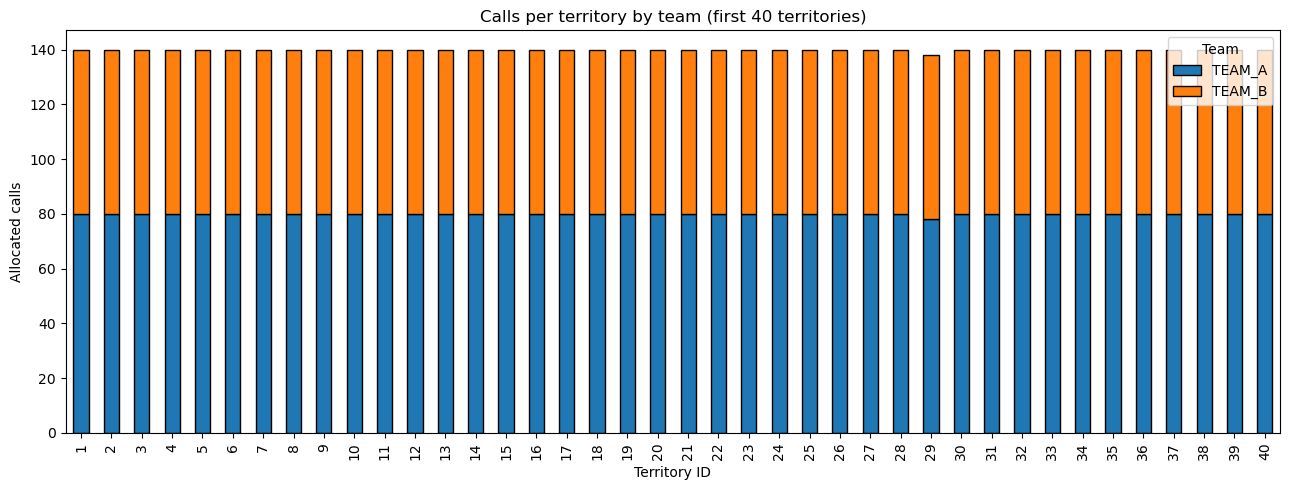

In [6]:
import matplotlib.pyplot as plt

pf = results.portfolio
pf = pf[(pf['Territory_ID'] != 0) & (pf['NPI_STR'] != '0')]
by_territory = (pf.groupby(['Territory_ID', 'ROW_SOURCE'])['ALLOCATED_CALLS']
                  .sum().unstack(fill_value=0))
by_territory = by_territory.head(40)  # first 40 territories for legibility

ax = by_territory.plot(kind='bar', stacked=True, figsize=(13, 5),
                       color=['#1f77b4', '#ff7f0e'], edgecolor='black')
ax.set_xlabel('Territory ID'); ax.set_ylabel('Allocated calls')
ax.set_title('Calls per territory by team (first 40 territories)')
ax.legend(title='Team')
plt.tight_layout(); plt.show()

## 6. Did the model learn anything? Backtest performance

In [7]:
pipeline.print_model_summary()


MODEL PERFORMANCE SUMMARY

  Probability Model:
    Avg PR-AUC:    0.9718
    Avg ROC-AUC:   0.9573
    Avg Recall:    1.0000
    Avg Precision: 0.5768

  Depth Model:
    Avg MAE: 4.4324
    Avg R2:  -5.2463

  Look-alike Model:
    Avg PR-AUC:    0.1713
    Avg ROC-AUC:   0.4853


## 7. Where does the call budget go in terms of HCP value?

              sum      mean  count
rx_decile                         
0           494.0  0.770671    641
2           651.0  0.870321    748
3           460.0  0.818505    562
4           446.0  0.963283    463
5           476.0  0.896422    531
6           741.0  1.357143    546
7          1011.0  2.088843    484
8          1128.0  2.132325    529
9           991.0  2.002020    495
10            0.0  0.000000      1


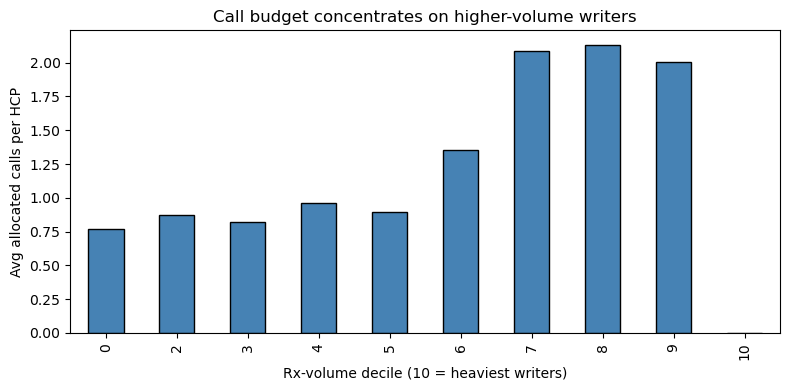

In [8]:
import matplotlib.pyplot as plt

# Merge calls with the reference table to see who got prioritised
ref = tables['hcp_reference'].copy()
ref['npi_int'] = ref['npi'].astype(int)
calls = (pf.assign(npi_int=lambda d: d['NPI_STR'].astype(int))
           .groupby('npi_int', as_index=False)['ALLOCATED_CALLS'].sum())
joined = ref.merge(calls, on='npi_int', how='left').fillna({'ALLOCATED_CALLS': 0})
joined['rx_total'] = joined['IL_17_TRX_L12M'] + joined['IL_23_TRX_L12M']
joined['rx_decile'] = (joined['rx_total'].rank(pct=True) * 10).clip(upper=10).astype(int)

decile_calls = joined.groupby('rx_decile')['ALLOCATED_CALLS'].agg(['sum', 'mean', 'count'])
print(decile_calls)

ax = decile_calls['mean'].plot(kind='bar', figsize=(8, 4),
                               color='steelblue', edgecolor='black')
ax.set_xlabel('Rx-volume decile (10 = heaviest writers)')
ax.set_ylabel('Avg allocated calls per HCP')
ax.set_title('Call budget concentrates on higher-volume writers')
plt.tight_layout(); plt.show()

## What you saw

The pipeline:
1. Built lag/rolling features per HCP×week
2. Trained three models (probability of referral, depth of referral,
   look-alike score) with walk-forward backtesting
3. Scored every HCP at every call-count scenario (0,1,2,3,4)
4. Solved a PuLP linear program to maximise expected referrals
   subject to per-territory call budgets, priority-target rules, and a
   soft slack penalty
5. Built a long-format portfolio with team labels and audit columns

All driven by one config object. To run on your real data: swap
`dataframes={...}` for table paths or Spark tables in the config and the
same pipeline runs unchanged.